In [8]:
import numpy as np
import xarray as xr
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
import pint
from pint import application_registry as ureg
import matplotlib.pyplot as plt
import intake

from os import environ
environ["PYTHONWARNINGS"] = "ignore"

In [10]:
!pip install dask_jobqueue

In [11]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client
cluster = SLURMCluster(
    memory="100GB",
    processes=8,
    cores=8,
    walltime="02:00:00",
    queue="dcgp_usr_prod",
    account="ICT26_ESP",
    interface="ib0",
    env_extra=[
        "export OMP_NUM_THREADS=1",
        "export MKL_NUM_THREADS=1",
        "export NUMBA_NUM_THREADS=1",
    ],
    job_extra=[
        "--nodes=1",
        "--ntasks-per-node=8",
        "--hint=nomultithread",
    ],
    log_directory="logs/"
)

cluster.scale(16)
client = Client(cluster)

client

/leonardo/home/userexternal/ntilinin/.venvs/ocean2/lib/python3.11/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/leonardo/home/userexternal/ntilinin/.venvs/ocean2/lib/python3.11/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarnin

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://10.128.0.1:8787/status,
Dashboard: http://10.128.0.1:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.128.0.1:42681,Workers: 0
Dashboard: http://10.128.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [12]:
%%time 

experiment = 'AccessOm2RYF_SPEEDY100YR'

CPU times: user 3 μs, sys: 1 μs, total: 4 μs
Wall time: 5.25 μs


In [13]:
%%time 
CATALOG = "/leonardo/home/userexternal/ntilinin/access-om2-catalog/AccessOm2RYF_SPEEDY100YR.json"

catalog = intake.open_esm_datastore(
    CATALOG,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units",
    ]
)

catalog

CPU times: user 12.8 s, sys: 1.02 s, total: 13.9 s
Wall time: 16.5 s


,unique
filename,37535
file_id,109
path,37760
filename_timestamp,30241
frequency,3
start_date,29281
end_date,29281
variable,234
variable_long_name,218
variable_standard_name,39


In [18]:
%%time 
CATALOG1 = "/leonardo/home/userexternal/ntilinin/access-om2-catalog/AccessOm2RYF_JRA55100YR.json"

catalog_jra = intake.open_esm_datastore(
    CATALOG1,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units",
    ]
)

CPU times: user 5.91 s, sys: 322 ms, total: 6.23 s
Wall time: 6.43 s


In [17]:
variable = "surface_pot_temp"

ds = catalog.search(
    variable=variable,
    frequency="1mon"
).to_dask()

sst = ds[variable]
sst

<xarray.DataArray 'surface_pot_temp' (time: 960, yt_ocean: 300, xt_ocean: 360)> Size: 415MB
dask.array<concatenate, shape=(960, 300, 360), dtype=float32, chunksize=(12, 300, 360), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) object 8kB 1900-01-16 12:00:00 ... 1979-12-16 12:00:00
  * yt_ocean  (yt_ocean) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * xt_ocean  (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 77.5 78.5 79.5
Attributes:
    long_name:      Potential temperature
    units:          K
    valid_range:    [-10. 500.]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_surface_temperature

In [19]:
variable = "surface_pot_temp"

ds = catalog_jra.search(
    variable=variable,
    frequency="1mon"
).to_dask()

sst_jra = ds[variable]
sst_jra

<xarray.DataArray 'surface_pot_temp' (time: 480, yt_ocean: 300, xt_ocean: 360)> Size: 207MB
dask.array<concatenate, shape=(480, 300, 360), dtype=float32, chunksize=(12, 300, 360), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) object 4kB 1900-01-16 12:00:00 ... 1939-12-16 12:00:00
  * yt_ocean  (yt_ocean) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * xt_ocean  (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 77.5 78.5 79.5
Attributes:
    long_name:      Potential temperature
    units:          K
    valid_range:    [-10. 500.]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_surface_temperature

In [6]:
print("dims:", sst.dims)
print("units:", sst.attrs.get("units"))
print("time:", sst.time.min().values, "→", sst.time.max().values)

dims: ('time', 'yt_ocean', 'xt_ocean')
units: K
time: 1900-01-16 12:00:00 → 1979-12-16 12:00:00


In [42]:
# Convert SST from K to °C
sst = (sst - 273.15).assign_attrs(
    units="degC",
    long_name="Sea Surface Temperature"
)
sst_jra = (sst_jra - 273.15).assign_attrs(
    units="degC",
    long_name="Sea Surface Temperature"
)

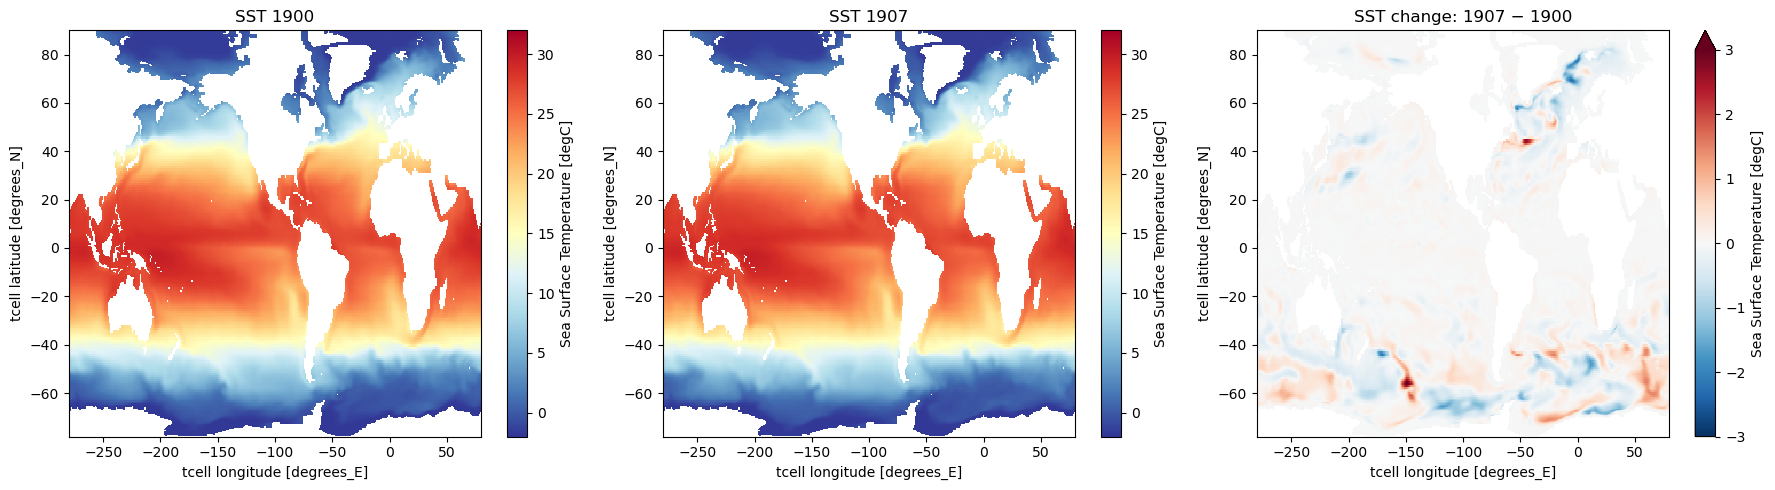

In [22]:
sst_1900 = sst_ann.sel(year=1920)
sst_1907 = sst_ann.sel(year=1940)
sst_diff = sst_1907 - sst_1900

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sst_1900.plot(ax=axs[0], vmin=-2, vmax=32, cmap="RdYlBu_r")
axs[0].set_title("SST 1900")

sst_1907.plot(ax=axs[1], vmin=-2, vmax=32, cmap="RdYlBu_r")
axs[1].set_title("SST 1907")

sst_diff.plot(ax=axs[2], vmin=-3, vmax=3, cmap="RdBu_r")
axs[2].set_title("SST change: 1907 − 1900")

plt.tight_layout()

In [10]:
GRID_PATH = "/leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2/archive/1deg_speedy_ryf-cosima100yr/output000/ocean"

area = xr.open_dataset(
    f"{GRID_PATH}/ocean-2d-area_t.nc"
)["area_t"]

area

<xarray.DataArray 'area_t' (yt_ocean: 300, xt_ocean: 360)> Size: 432kB
[108000 values with dtype=float32]
Coordinates:
  * yt_ocean  (yt_ocean) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * xt_ocean  (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 77.5 78.5 79.5
Attributes:
    long_name:     tracer cell area
    units:         m^2
    valid_range:   [0.e+00 1.e+15]
    cell_methods:  time: point

In [25]:
# Ocean mask + area weights
weights = area.where(sst_ann.isel(year=0).notnull(), 0)

In [45]:
# # Global area-weighted annual mean SST
sst_ann=sst.groupby("time.year").mean("time")
sst_global=sst_ann.weighted(weights).mean(("yt_ocean","xt_ocean")).compute(scheduler="single-threaded")
sst_ann_jra=sst_jra.groupby("time.year").mean("time")
sst_global_jra=sst_ann_jra.weighted(weights).mean(("yt_ocean","xt_ocean")).compute(scheduler="single-threaded")

/leonardo/home/userexternal/ntilinin/.conda/envs/ocean/lib/python3.11/site-packages/dask/base.py:1119: UserWarning: Running on a single-machine scheduler when a distributed client is active might lead to unexpected results.
  warnings.warn(
/leonardo/home/userexternal/ntilinin/.conda/envs/ocean/lib/python3.11/site-packages/dask/base.py:1119: UserWarning: Running on a single-machine scheduler when a distributed client is active might lead to unexpected results.
  warnings.warn(


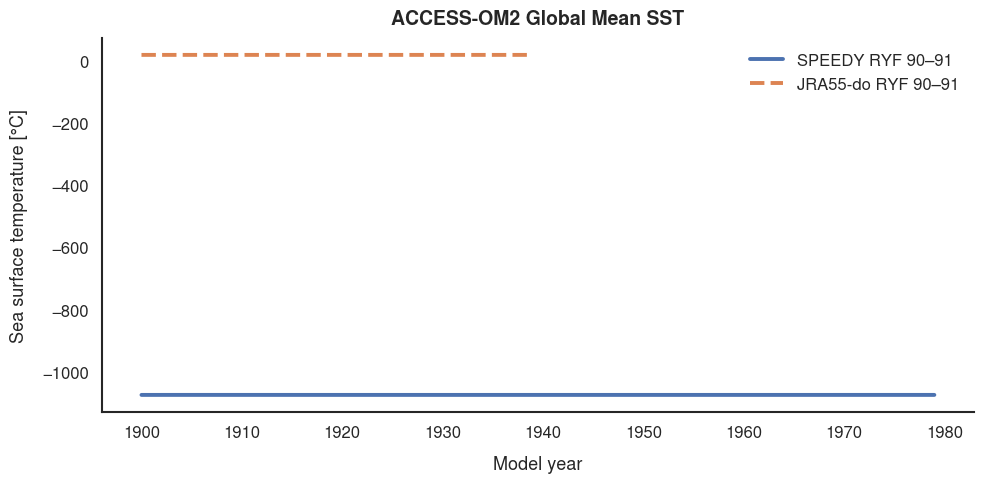

In [46]:
import seaborn as sns, matplotlib.pyplot as plt

sns.set_theme(style="white"); plt.rcParams.update({"font.family": "Nimbus Sans"})

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sst_global.year, sst_global, linewidth=2.8, label="SPEEDY RYF 90–91")
ax.plot(sst_global_jra.year, sst_global_jra, linewidth=2.8, linestyle="--", label="JRA55-do RYF 90–91")

ax.set_title("ACCESS-OM2 Global Mean SST", fontsize=14, pad=10, fontweight="bold")
ax.set_ylabel("Sea surface temperature [°C]", fontsize=13, labelpad=10)
ax.set_xlabel("Model year", fontsize=13, labelpad=10)
ax.tick_params(axis="both", labelsize=12, width=1.2)

ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5); ax.spines["bottom"].set_linewidth(1.5)

ax.legend(frameon=False, fontsize=12)
fig.tight_layout()
plt.show()

In [34]:
delta_sst = sst_global.sel(year=1907) - sst_global.sel(year=1900)

print(f"SST 1900: {float(sst_global.sel(year=1900)):.3f} °C")
print(f"SST 1907: {float(sst_global.sel(year=1907)):.3f} °C")
print(f"1907 - 1900: {float(delta_sst):+.3f} °C")

SST 1900: 18.154 °C
SST 1907: 18.176 °C
1907 - 1900: +0.022 °C


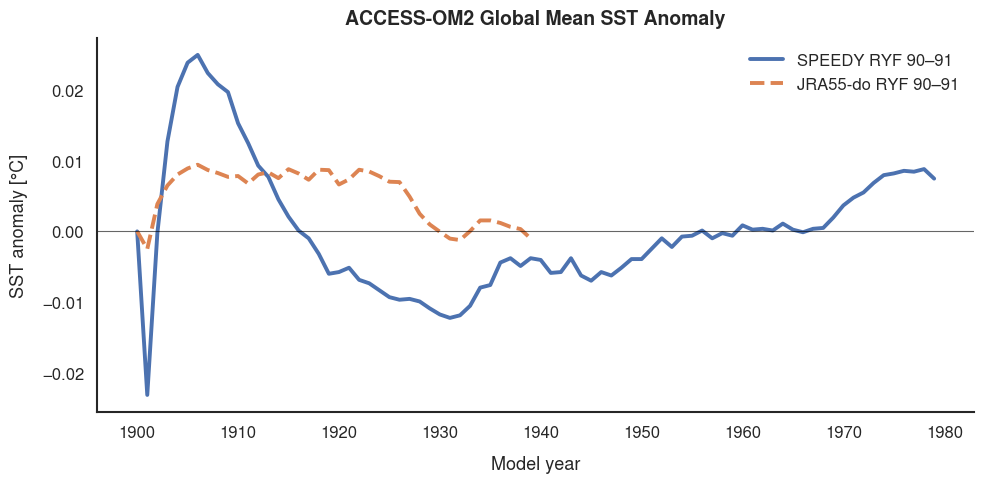

In [47]:
import seaborn as sns, matplotlib.pyplot as plt

sst_anom = sst_global - sst_global.isel(year=0)
sst_anom_jra = sst_global_jra - sst_global_jra.isel(year=0)

sns.set_theme(style="white"); plt.rcParams.update({"font.family": "Nimbus Sans"})

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sst_anom.year, sst_anom, linewidth=2.8, label="SPEEDY RYF 90–91")
ax.plot(sst_anom_jra.year, sst_anom_jra, linewidth=2.8, linestyle="--", label="JRA55-do RYF 90–91")
ax.axhline(0, linewidth=0.8, color="black", alpha=0.6)

ax.set_title("ACCESS-OM2 Global Mean SST Anomaly", fontsize=14, pad=10, fontweight="bold")
ax.set_ylabel("SST anomaly [°C]", fontsize=13, labelpad=10)
ax.set_xlabel("Model year", fontsize=13, labelpad=10)
ax.tick_params(axis="both", labelsize=12, width=1.2)

ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5); ax.spines["bottom"].set_linewidth(1.5)

ax.legend(frameon=False, fontsize=12)
fig.tight_layout()
plt.show()

In [48]:
client.close()
cluster.close()

/leonardo/home/userexternal/ntilinin/.conda/envs/ocean/lib/python3.11/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/leonardo/home/userexternal/ntilinin/.conda/envs/ocean/lib/python3.11/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, Futu